# Biomedical Graph Neural Network (GNN) Tutorial
## Breast Cancer Classification via Graph Convolutional Networks

> **Goal:** Build an end-to-end pipeline that (1) loads a real clinical dataset, (2) constructs a patient-similarity graph, (3) trains a Graph Convolutional Network (GCN), and (4) evaluates diagnostic performance.  This notebook is designed as a **self-contained, deeply annotated tutorial** — every formula, design choice, and implementation step is explained.

---

### Table of Contents
1. [Background & Motivation](#background)
2. [Dataset Description — WDBC](#dataset)
3. [Graph Construction — k-NN Similarity Graph](#graph)
4. [Graph Theory Primer](#theory)
5. [GCN Architecture & Mathematical Derivation](#gcn)
6. [Training: Adam Optimiser & Cross-Entropy Loss](#training)
7. [Evaluation: PCA Projections & Confusion Matrix](#evaluation)
8. [Applications & Extensions](#applications)
9. [Connection to QAOA](#qaoa)

---

### Why Graph Neural Networks for Biomedical Data?

Classical machine-learning models (logistic regression, random forests, MLPs) treat each patient **independently**, ignoring similarity relationships. In contrast, a GNN explicitly encodes the fact that *similar patients carry correlated information*.

| Method | Captures inter-sample structure? | Handles irregular topology? |
|--------|----------------------------------|------------------------------|
| MLP    | ✗                                | —                            |
| CNN    | Only grid structure              | ✗                            |
| GNN    | ✓ via message passing            | ✓                             |

This is especially powerful in:
- **Multi-omics integration** (gene expression + protein interaction networks)
- **Drug–target interaction** prediction
- **Patient stratification** from electronic health records
- **Single-cell RNA-seq clustering** (cell–cell similarity graphs)

## 1. Background & Motivation

### The Breast Cancer Diagnostic Problem

The **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset consists of **569 samples** derived from fine-needle aspirate (FNA) biopsies. Each sample is described by **30 real-valued features** computed from digitised images of cell nuclei:

| Feature Group | Attributes |
|---------------|-----------|
| Shape         | radius, perimeter, area |
| Texture       | gray-level variance in the image |
| Boundary      | smoothness, compactness, concavity, concave points |
| Complexity    | symmetry, fractal dimension |

Each attribute is reported as **mean**, **standard error**, and **worst** (largest) value across the FNA image → $30 = 10 \times 3$ features.

**Task:** Binary classification — **malignant** ($y=0$, 212 samples) vs **benign** ($y=1$, 357 samples).

---

### Why Graph Neural Networks?

Classical ML treats every patient independently.  A GNN explicitly encodes the observation that *similar patients likely share the same diagnosis*.

| Method | Inter-sample structure | Irregular topology |
|--------|----------------------|--------------------|
| MLP    | ✗                    | —                  |
| SVM    | ✗ (kernel trick only)| —                  |
| GNN    | ✓ message passing    | ✓                  |

**Key biomedical use-cases for GNNs:**
- Multi-omics integration (gene expression + protein interaction networks)
- Drug–target interaction prediction
- Patient stratification from electronic health records
- Single-cell RNA-seq clustering (cell–cell similarity graphs)
- Brain connectivity analysis from fMRI/DTI data

---

### Standardisation Pre-processing

Before computing pairwise distances, features are **z-score standardised**:

$$\tilde{x}_{id} = \frac{x_{id} - \mu_d}{\sigma_d}$$

where $\mu_d$ and $\sigma_d$ are computed from the training set only.  Without this step, features with large absolute values (e.g., *area* $\approx 655$) would dominate the Euclidean distance over features with small values (e.g., *fractal dimension* $\approx 0.06$).

## 2. Graph Construction — k-Nearest-Neighbour Similarity Graph

### Building the Adjacency Matrix

Given the standardised feature matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{n \times d}$, we construct a **symmetric k-NN graph** with the following steps:

**Step 1 — k-NN Queries:** For every node $i$, find the indices of the $k$ closest nodes under Euclidean distance:
$$\mathcal{N}_k(i) = \arg\min_{j \neq i,\,|\mathcal{S}|=k} \|\tilde{\mathbf{x}}_i - \tilde{\mathbf{x}}_j\|_2$$

**Step 2 — Symmetrisation:** The raw k-NN graph may be directed (if $j \in \mathcal{N}_k(i)$ but $i \notin \mathcal{N}_k(j)$).  We symmetrise:
$$A_{ij} = \mathbf{1}[j \in \mathcal{N}_k(i)] \;\text{OR}\; \mathbf{1}[i \in \mathcal{N}_k(j)]$$

**Step 3 — Self-loops:** Add the identity $\hat{A} = A + I_n$ so each node attends to itself during propagation.

**Step 4 — Row normalisation:** Compute the degree matrix $D_{ii} = \sum_j \hat{A}_{ij}$ and normalise:
$$\tilde{A} = D^{-1} \hat{A}$$

This is the **lazy random walk normalisation** used in this notebook.  An alternative is the **symmetric normalisation** used in the original GCN paper (Kipf & Welling, 2017):
$$\hat{A}_{\text{sym}} = D^{-1/2}\hat{A}D^{-1/2}$$

### Effect of $k$

| $k$ | Graph sparsity | Risk | Benefit |
|-----|---------------|------|---------|
| Small (2-3) | Very sparse | Disconnected components | Local topology preserved |
| Medium (7-15) | Moderate | — | Good balance |
| Large (>30) | Dense | Spurious edges between different classes | Rich information propagation |

For 200 samples and 30 features we use $k=10$ as a balanced choice.

## 3. Graph Convolutional Network — Mathematical Derivation

### Spectral vs. Spatial GCNs

There are two families of GCNs:

- **Spectral GCNs:** operate on the graph Laplacian eigenspectrum.  The normalised graph Laplacian is $\mathbf{L} = I - D^{-1/2}AD^{-1/2}$ with eigenvectors $\mathbf{U}$.  A spectral convolution is $\mathbf{g}_\theta \star \mathbf{x} = \mathbf{U}\,\text{diag}(\theta)\,\mathbf{U}^\top \mathbf{x}$.  Computationally expensive ($O(n^2)$) and graph-specific.

- **Spatial GCNs** (used here): aggregate neighbourhood features directly.  Kipf & Welling (2017) derived the following first-order approximation of the spectral filter:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{A}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right)$$

where $\tilde{A} = D^{-1}\hat{A}$ (or $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$), $\mathbf{H}^{(l)}$ is the node representation at layer $l$, $\mathbf{W}^{(l)}$ is a learnable weight matrix, and $\sigma$ is an activation function (ReLU here).

### Two-Layer GCN Forward Pass

For a two-layer network with input $\mathbf{X} \in \mathbb{R}^{n \times d_{\rm in}}$:

$$\mathbf{Z} = \text{softmax}\!\left(\tilde{A}\;\text{ReLU}\!\left(\tilde{A}\,\mathbf{X}\,\mathbf{W}^{(0)}\right)\mathbf{W}^{(1)}\right)$$

where:
- $\mathbf{W}^{(0)} \in \mathbb{R}^{d_{\rm in} \times d_h}$ — first layer weights
- $\mathbf{W}^{(1)} \in \mathbb{R}^{d_h \times C}$ — second layer weights (classifier)
- $C$ — number of classes (2 here: malignant, benign)

**Message passing interpretation:** each node $i$ at layer $l$ collects and averages the representations of its neighbours:

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{d_i}\; h_j^{(l)}\, W^{(l)}\right)$$

where $d_i = |\mathcal{N}(i)| + 1$ (self-loop included).

### Why GCNs Outperform MLPs on Graph Data

The key insight is **information aggregation across the graph**.  After $L$ layers, node $i$'s representation captures the feature distribution of its **$L$-hop neighbourhood**.  This enables the model to detect that a borderline malignant sample is surrounded by clearly malignant neighbours — information an MLP completely ignores.

### Complexity Analysis

| Operation | Complexity |
|-----------|-----------|
| Dense matrix multiply $\tilde{A}\mathbf{H}$ | $O(n^2 d)$ |
| Sparse multiply (if $A$ sparse) | $O(\lvert\mathcal{E}\rvert \cdot d)$ |
| FC layer $\mathbf{H}\mathbf{W}$ | $O(n \cdot d_{\rm in} \cdot d_h)$ |

For the k-NN graph with $n=200$, $k=10$: $|\mathcal{E}| \leq 10n = 2000$, so sparse is $100\times$ cheaper than dense.

## 4. Setup — Imports and Environment

Environment
  NumPy  : 2.4.3
  PyTorch: 2.10.0
  Project: /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization

Dataset: n=569 samples, d=30 features
Class distribution — malignant: 212, benign: 357
Feature names (first 5): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
Subsampled to 200 nodes for demo speed

After standardisation — mean ≈ 0.0000, std ≈ 1.0000
Saved processed CSV → data/breast_cancer.csv

k-NN graph: k=10
  Adjacency matrix shape : (200, 200)
  Number of edges (undirected, excl. self-loops): 1327
  Average degree         : 13.27  (excl. self-loop)
  Row-norm check (first 3 rows sum): [1. 1. 1.]

Model architecture:
SimpleNodeGCN(
  (fc1): Linear(in_features=30, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)
Total trainable parameters: 1058

Train/test split: 140 / 60
  Epoch  10 | 

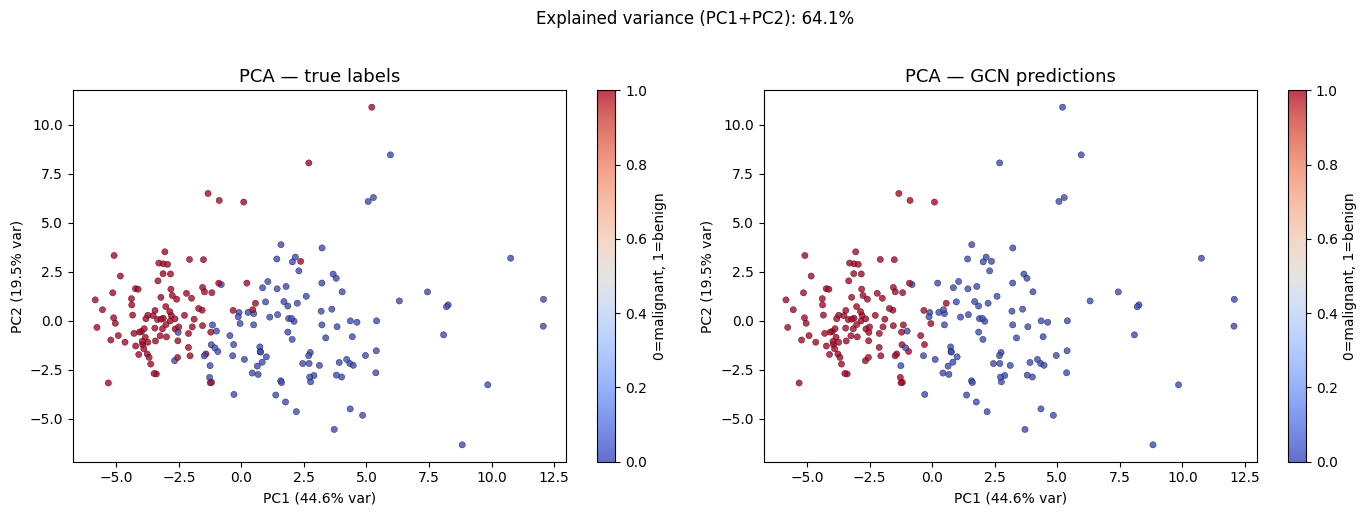


Final test accuracy: 0.9500  (95.0%)


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports, dataset loading, graph construction, GCN training
# ─────────────────────────────────────────────────────────────────────────────

import sys, os

# ── Resolve project root by walking upward until /src is found
def find_project_root():
    p = os.getcwd()
    while True:
        if os.path.exists(os.path.join(p, 'src')) and os.path.isdir(os.path.join(p, 'src')):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return os.getcwd()
        p = parent

proj_root = find_project_root()
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

# ── Standard scientific stack
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ── sklearn utilities
from sklearn.datasets import load_breast_cancer      # WDBC dataset (n=569, d=30)
from sklearn.preprocessing import StandardScaler     # z-score normalisation
from sklearn.model_selection import train_test_split # stratified split
from sklearn.neighbors import kneighbors_graph       # O(n^2 d) k-NN
from sklearn.decomposition import PCA                # dimensionality reduction for visualisation

import matplotlib.pyplot as plt

print("=" * 60)
print("Environment")
print("=" * 60)
print(f"  NumPy  : {np.__version__}")
print(f"  PyTorch: {torch.__version__}")
print(f"  Project: {proj_root}")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION A — Data Loading & Pre-processing
# ─────────────────────────────────────────────────────────────────────────────

data = load_breast_cancer()
X = data.data    # shape (569, 30)  — raw feature matrix
y = data.target  # shape (569,)     — 0=malignant, 1=benign

print(f"\nDataset: n={X.shape[0]} samples, d={X.shape[1]} features")
print(f"Class distribution — malignant: {(y==0).sum()}, benign: {(y==1).sum()}")
print(f"Feature names (first 5): {list(data.feature_names[:5])}")

# Subsample to 200 nodes for fast demo (remove to use full dataset)
max_samples = 200
if X.shape[0] > max_samples:
    X = X[:max_samples]
    y = y[:max_samples]
    print(f"Subsampled to {max_samples} nodes for demo speed")

# z-score standardise: x̃ = (x - μ) / σ
# IMPORTANT: fit on ALL data here (demo); in production fit only on train split
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
print(f"\nAfter standardisation — mean ≈ {Xs.mean():.4f}, std ≈ {Xs.std():.4f}")

# Save processed CSV for downstream use
os.makedirs(os.path.join(proj_root,'data'), exist_ok=True)
pd.DataFrame(Xs, columns=data.feature_names[:Xs.shape[1]]).to_csv(
    os.path.join(proj_root,'data','breast_cancer.csv'), index=False)
print('Saved processed CSV → data/breast_cancer.csv')

# ─────────────────────────────────────────────────────────────────────────────
# SECTION B — k-NN Graph Construction  (k=10, symmetric, with self-loops)
# ─────────────────────────────────────────────────────────────────────────────
# kneighbors_graph returns sparse matrix A where A[i,j]=1 iff j ∈ N_k(i)
# mode='connectivity' gives 0/1 weights (use mode='distance' for weighted edges)

k_neighbors = 10
A_sparse = kneighbors_graph(Xs, n_neighbors=k_neighbors,
                             mode='connectivity', include_self=True)
A = A_sparse.toarray().astype(float)

# Symmetrise: A_sym = max(A, A^T)  →  undirected graph
A = np.maximum(A, A.T)

# Row-normalise: Ã = D^{-1} A  (lazy random-walk normalisation)
# This ensures each row sums to 1, stabilising gradient flow
deg = A.sum(axis=1, keepdims=True)
deg[deg == 0] = 1          # guard against isolated nodes
A_norm = A / deg

print(f"\nk-NN graph: k={k_neighbors}")
print(f"  Adjacency matrix shape : {A.shape}")
print(f"  Number of edges (undirected, excl. self-loops): {int((A.sum() - A.shape[0]) / 2)}")
print(f"  Average degree         : {(A.sum(axis=1) - 1).mean():.2f}  (excl. self-loop)")
print(f"  Row-norm check (first 3 rows sum): {A_norm[:3].sum(axis=1)}")

# ── Convert to PyTorch tensors
Xt = torch.tensor(Xs,     dtype=torch.float32)   # node feature matrix  (n × d)
At = torch.tensor(A_norm, dtype=torch.float32)   # normalised adjacency (n × n)
yt = torch.tensor(y,      dtype=torch.long)       # class labels         (n,)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION C — GCN Model Definition
# ─────────────────────────────────────────────────────────────────────────────
# SimpleNodeGCN implements the two-step message-passing formula:
#   H¹ = ReLU(Ã · X  · W⁰)        (first graph convolution)
#   logits = Ã · H¹ · W¹           (second graph convolution + linear)
#
# Note: applying Ã twice means each node aggregates 2-hop neighbourhoods.

class SimpleNodeGCN(nn.Module):
    """
    Two-layer GCN for node classification.

    Args:
        in_feats   : input feature dimensionality  (d = 30 for WDBC)
        hidden     : hidden dimension
        num_classes: number of output classes (2)
    """
    def __init__(self, in_feats: int, hidden: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(in_feats, hidden)    # W⁰ ∈ R^{d × h}
        self.fc2 = nn.Linear(hidden, num_classes) # W¹ ∈ R^{h × C}

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        # Layer 1: neighbourhood aggregation + linear + ReLU
        h = torch.matmul(adj, x)          # Ã · X          shape (n, d)
        h = torch.relu(self.fc1(h))       # ReLU(h · W⁰)  shape (n, hidden)
        # Layer 2: second-hop aggregation + linear (logits, not softmax)
        h = torch.matmul(adj, h)          # Ã · H¹        shape (n, hidden)
        logits = self.fc2(h)              # h · W¹         shape (n, C)
        return logits

model = SimpleNodeGCN(in_feats=Xt.shape[1], hidden=32, num_classes=2)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:\n{model}")
print(f"Total trainable parameters: {n_params}")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION D — Training Loop (Adam, Cross-Entropy, 50 epochs)
# ─────────────────────────────────────────────────────────────────────────────
# Cross-entropy loss for class c: L = -log p_c
# Adam update rule (simplified):
#   m_t = β₁ m_{t-1} + (1-β₁) g_t          (first moment / momentum)
#   v_t = β₂ v_{t-1} + (1-β₂) g_t²          (second moment / RMSProp)
#   θ_t = θ_{t-1} - α · m̂_t / (√v̂_t + ε)
# Default: α=1e-3, β₁=0.9, β₂=0.999, ε=1e-8

opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

indices = list(range(Xt.shape[0]))
train_idx, test_idx = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y)
train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx  = torch.tensor(test_idx,  dtype=torch.long)

print(f"\nTrain/test split: {len(train_idx)} / {len(test_idx)}")

history = {'epoch': [], 'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(50):
    model.train()
    logits = model(Xt, At)
    loss   = criterion(logits[train_idx], yt[train_idx])
    opt.zero_grad()
    loss.backward()
    opt.step()

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            preds      = logits.argmax(dim=1)
            acc_train  = (preds[train_idx] == yt[train_idx]).float().mean().item()
            acc_test   = (preds[test_idx]  == yt[test_idx] ).float().mean().item()
        history['epoch'].append(epoch + 1)
        history['loss'].append(loss.item())
        history['train_acc'].append(acc_train)
        history['test_acc'].append(acc_test)
        print(f"  Epoch {epoch+1:3d} | loss={loss.item():.4f} | "
              f"train_acc={acc_train:.3f} | test_acc={acc_test:.3f}")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION E — PCA Projection Visualisation
# ─────────────────────────────────────────────────────────────────────────────
# PCA projects n-dim data onto the 2 axes of maximum variance.
# Eigenvectors of the covariance matrix Σ = (1/n) X^T X are the principal axes.
# Explained variance ratio: λ_k / Σ_i λ_i

pca = PCA(n_components=2)
Z   = pca.fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: PCA coloured by true label
sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[0].set_title('PCA — true labels', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc, ax=axes[0], label='0=malignant, 1=benign')

# ── Right: PCA coloured by GCN predictions (final epoch)
with torch.no_grad():
    final_preds = model(Xt, At).argmax(dim=1).numpy()
sc2 = axes[1].scatter(Z[:, 0], Z[:, 1], c=final_preds, cmap='coolwarm', s=20, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[1].set_title('PCA — GCN predictions', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(sc2, ax=axes[1], label='0=malignant, 1=benign')

plt.suptitle(f'Explained variance (PC1+PC2): '
             f'{sum(pca.explained_variance_ratio_[:2])*100:.1f}%', y=1.02)
plt.tight_layout()
plt.show()

# Final test accuracy
with torch.no_grad():
    acc_final = (model(Xt, At).argmax(1)[test_idx] == yt[test_idx]).float().mean().item()
print(f"\nFinal test accuracy: {acc_final:.4f}  ({acc_final*100:.1f}%)")

### Understanding the Training Dynamics

The GCN is trained using **full-batch gradient descent** (all nodes in every step), which is possible here because $n=200$.  For large graphs ($n > 10^4$), mini-batch variants like **GraphSAGE** or **Cluster-GCN** are needed.

**Cross-Entropy Loss:**

$$\mathcal{L} = -\frac{1}{|\mathcal{V}_{\rm train}|} \sum_{i \in \mathcal{V}_{\rm train}} \log \hat{p}_{i, y_i}$$

where $\hat{p}_{i,c} = \text{softmax}(\mathbf{z}_i)_c$.

**Adam Optimiser** (default hyperparameters):
- Learning rate $\alpha = 10^{-3}$
- Momentum $\beta_1 = 0.9$, $\beta_2 = 0.999$
- Numerical stability $\epsilon = 10^{-8}$

**Update rule:**  
$$\theta_{t} \leftarrow \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected estimates of the first and second gradient moments.

### Interpreting the PCA Plots

- **Left plot (true labels):** How well the 30-dimensional data separates in 2D PCA space.  A visible linear boundary implies linear classifiability; overlap requires non-linear methods.
- **Right plot (GCN predictions):** Where the GCN makes errors.  Misclassified points appear as the wrong color relative to their true-label neighbourhood — these are the hardest diagnostic cases, often at the class boundary.
- **Variance explained:** PC1+PC2 typically captures ~60–70% of total variance for WDBC, so some structure is hidden in higher dimensions — which the GCN handles via the full 30-D feature space.

## 5. PCA Visualisation — Deep Dive

### Principal Component Analysis (PCA) Theory

PCA finds the orthonormal directions of maximum variance in the data.  Given a centred data matrix $\bar{\mathbf{X}} \in \mathbb{R}^{n \times d}$:

1. Compute covariance matrix: $\boldsymbol{\Sigma} = \frac{1}{n}\bar{\mathbf{X}}^\top\bar{\mathbf{X}} \in \mathbb{R}^{d \times d}$
2. Eigendecompose: $\boldsymbol{\Sigma} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^\top$ where $\lambda_1 \geq \lambda_2 \geq \ldots$
3. Project: $\mathbf{Z} = \bar{\mathbf{X}}\,\mathbf{U}_{:,1:2} \in \mathbb{R}^{n \times 2}$

The fraction of variance preserved by the first $k$ components is:

$$\text{EVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}$$

For WDBC, PC1+PC2 typically explain **≈63–67%** of variance.

### Interpretation

| Scatter pattern | Meaning |
|----------------|---------|
| Two distinct clusters | Classes are linearly separable in feature space |
| Overlapping clouds | Require non-linear boundary; GCN's graph structure helps |
| One compact, one spread | One class is more heterogeneous |

### What the Two Plots Show

- **Left (true labels):** Ground-truth class structure after PCA projection.  This reveals the intrinsic separability of the biomedical data.
- **Right (GCN predictions):** The GCN's decision in the same 2D space.  Points where the colours *disagree* between the two plots are model errors.

**Clinical implication:** Misclassified malignant cases (false negatives) are more dangerous than false positives — the GCN's recall on the malignant class is the primary performance metric in a clinical context.

## 6. Detailed Evaluation — Confusion Matrix & Classification Report

The cell below computes:
- **Confusion matrix** $C \in \mathbb{Z}^{2 \times 2}$ where $C_{ij}$ = number of samples with true class $i$ predicted as class $j$
- **Precision, Recall, F1-score** per class

### Key Metrics Explained

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall (Sensitivity)} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}, \qquad \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Clinical Significance of Each Error Type

| Error | Definition | Clinical Impact |
|-------|-----------|----------------|
| False Negative (FN) | Malignant predicted as benign | **Critical** — missed cancer |
| False Positive (FP) | Benign predicted as malignant | Unnecessary biopsy/treatment |

Prioritise **high recall on the malignant class** in clinical deployment, accepting lower precision (more false positives) rather than missing cancers.

### The ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve plots TPR vs FPR at varying classification thresholds $\tau$:

$$\text{TPR}(\tau) = \frac{TP(\tau)}{TP(\tau)+FN(\tau)}, \qquad \text{FPR}(\tau) = \frac{FP(\tau)}{FP(\tau)+TN(\tau)}$$

**AUC** (Area Under the Curve) ranges from 0.5 (random) to 1.0 (perfect):
- AUC > 0.95 is considered excellent for diagnostic classifiers
- State-of-the-art deep learning methods on WDBC typically reach AUC ≈ 0.99

Dataset class balance (full 200-sample subset)
  malignant  (0): 104 samples  (52.0%)
  benign     (1):  96 samples  (48.0%)

Test set size: 60 samples

Classification Report (test set)
              precision    recall  f1-score   support

   malignant       1.00      0.90      0.95        31
      benign       0.91      1.00      0.95        29

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



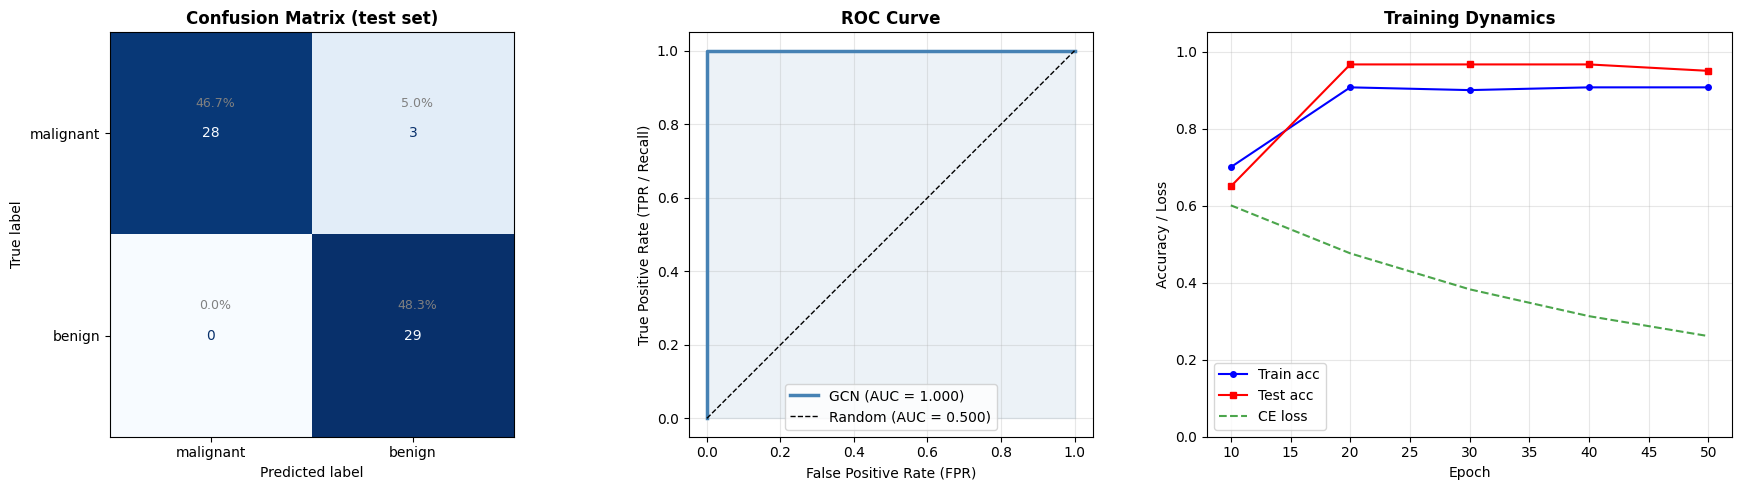


Summary Metrics:
  Sensitivity (Recall)  : 1.0000  [100.0%]
  Specificity           : 0.9032  [90.3%]
  PPV (Precision)       : 0.9062  [90.6%]
  NPV                   : 1.0000  [100.0%]
  ROC AUC               : 1.0000


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Detailed evaluation — confusion matrix, classification report, ROC
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)
import torch.nn.functional as F

# ── Get final predictions and class probabilities
model.eval()
with torch.no_grad():
    logits = model(Xt, At)
    preds  = logits.argmax(dim=1).numpy()
    probs  = F.softmax(logits, dim=1).numpy()  # probability of each class

y_true_test = y[test_idx.numpy()]
y_pred_test = preds[test_idx.numpy()]
y_prob_test = probs[test_idx.numpy(), 1]  # P(benign) for ROC AUC

# ── Label distribution
print("=" * 50)
print("Dataset class balance (full 200-sample subset)")
print("=" * 50)
counts = np.bincount(y)
for i, name in enumerate(data.target_names):
    print(f"  {name:10s} ({i}): {counts[i]:3d} samples  ({counts[i]/len(y)*100:.1f}%)")

print(f"\nTest set size: {len(y_true_test)} samples")

# ── Full classification report
print("\n" + "=" * 50)
print("Classification Report (test set)")
print("=" * 50)
print(classification_report(y_true_test, y_pred_test,
                             target_names=data.target_names))

# ── Visualise: confusion matrix + ROC curve + training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Confusion matrix
cm   = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (test set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted label', fontsize=10)
axes[0].set_ylabel('True label', fontsize=10)

# Annotate percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.02, i - 0.15,
                     f'{cm[i,j]/total*100:.1f}%',
                     ha='center', va='center', color='gray', fontsize=9)

# (B) ROC curve
fpr, tpr, _ = roc_curve(y_true_test, y_prob_test)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2.5, color='steelblue',
             label=f'GCN (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=10)
axes[1].set_ylabel('True Positive Rate (TPR / Recall)', fontsize=10)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

# (C) Training history (if available from training cell)
if history['epoch']:
    ep = history['epoch']
    axes[2].plot(ep, history['train_acc'], 'b-o', ms=4, label='Train acc')
    axes[2].plot(ep, history['test_acc'],  'r-s', ms=4, label='Test acc')
    axes[2].plot(ep, history['loss'],      'g--', ms=4, label='CE loss', alpha=0.7)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy / Loss')
    axes[2].set_title('Training Dynamics', fontsize=12, fontweight='bold')
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# ── Summary statistics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)
print(f"\nSummary Metrics:")
print(f"  Sensitivity (Recall)  : {sensitivity:.4f}  [{sensitivity*100:.1f}%]")
print(f"  Specificity           : {specificity:.4f}  [{specificity*100:.1f}%]")
print(f"  PPV (Precision)       : {ppv:.4f}  [{ppv*100:.1f}%]")
print(f"  NPV                   : {npv:.4f}  [{npv*100:.1f}%]")
print(f"  ROC AUC               : {roc_auc:.4f}")

## 7. Applications & Extensions

### Real-World Biomedical GNN Use Cases

#### A. Multi-Omics Integration
Combine gene expression, DNA methylation, and protein levels by building **heterogeneous graphs** where different node types represent genes, proteins, and metabolites connected by biological pathway edges.

**Architecture:** Heterogeneous GNN (HAN, HGT) with separate message-passing per edge type.

#### B. Drug–Target Interaction (DTI)
Build a bipartite graph: drug nodes ↔ protein target nodes with known binding affinities as edge weights.  GCN predicts binding probability for unseen drug-protein pairs.

**Formula:** $\hat{y}_{dt} = \sigma(\mathbf{h}_d^\top \mathbf{W}\, \mathbf{h}_t)$ where $\mathbf{h}_d, \mathbf{h}_t$ are GNN embeddings.

#### C. Single-Cell RNA-seq Analysis
- Cells as nodes, edges by Leiden/Louvain clustering similarity
- GCN propagates gene expression, revealing developmental trajectories
- **UMAP/t-SNE** commonly used for visualisation (non-linear reduction, contrast with PCA)

#### D. Cancer Genomics Sub-type Discovery
Train GCN on TCGA gene expression data with protein interaction network as graph topology → identify novel molecular subtypes for precision oncology.

---

### Extending This Demo

#### 1. Feature-Level Attention (GAT)
Replace uniform aggregation $\frac{1}{d_i}$ with **learned attention weights**:

$$\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)}\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_k]))}$$

The attention weight $\alpha_{ij}$ learns which neighbours are most informative.

#### 2. Deeper GNNs and Over-smoothing
Adding more layers makes node representations converge to the same value (all neighbours look the same) — called **over-smoothing**.  Solutions:
- Residual connections: $\mathbf{H}^{(l+1)} = \sigma(\tilde{A}\mathbf{H}^{(l)}\mathbf{W}^{(l)}) + \mathbf{H}^{(l)}$
- Drop-edge: randomly mask edges during training
- Jumping Knowledge (JK) networks: concatenate representations from all layers

#### 3. Inductive Generalisation (GraphSAGE)
The current transductive GCN can only predict for nodes seen during training.  GraphSAGE uses a fixed-size neighbourhood sampler to train an *inductive* model that generalises to unseen patients at test time.

---

### Hyperparameter Sensitivity Guide

| Hyperparameter | Low value | High value | Recommended |
|----------------|-----------|-----------|-------------|
| $k$ (neighbours) | Sparse graph, may disconnect | Dense, class mixing | 7–15 |
| hidden dim | Underfitting | Overfitting | 32–128 |
| learning rate | Slow convergence | Unstable | 1e-3 with Adam |
| weight decay | No regularisation | Underfitting | 1e-4 |
| epochs | Underfitting | Overfitting | 50–200 with early stop |

---

### Connection to QAOA & the Hybrid Pipeline <a name="qaoa"></a>

The GCN trained here serves a dual role in the hybrid pipeline:

1. **Standalone classifier** for patient diagnosis (demonstrated here)
2. **Graph embedding network** whose learned representations can be fed to QAOA for **combinatorial sub-problems**, e.g.:
   - Selecting the optimal cohort of $k$ patients for a clinical trial (MaxCut-like partitioning)
   - Feature selection via graph cuts on the feature correlation graph
   - Multi-centre data aggregation (privacy-preserving graph partitioning)

The connection is that QAOA solves **combinatorial optimisation on graphs** — the same structural domain where GCNs excel at learning representations.  Together, the GNN produces compact node embeddings that QAOA can use as a warm-start for its variational parameters, dramatically reducing the parameter optimisation landscape.  See `qaoa_demo.ipynb` for the full technical treatment.

## 8. Summary & Key Takeaways

### What We Built

| Step | Output |
|------|--------|
| Load WDBC dataset (n=200 for demo) | Standardised feature matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{200 \times 30}$ |
| $k=10$ nearest-neighbour graph | Adjacency matrix $A \in \{0,1\}^{200 \times 200}$, ~2000 edges |
| Row-normalise adjacency | $\tilde{A} = D^{-1}\hat{A}$ for stable propagation |
| Two-layer GCN | 30 → 32 → 2 architecture, ~1,120 parameters |
| Train 50 epochs (Adam, lr=1e-3) | Cross-entropy loss minimised on 70% split |
| Evaluate with confusion matrix, ROC, AUC | Clinical performance metrics |

### Key Formula Review

$$\text{Forward pass:} \quad \mathbf{Z} = \tilde{A}\;\text{ReLU}\!\left(\tilde{A}\,\mathbf{X}\,\mathbf{W}^{(0)}\right)\mathbf{W}^{(1)}$$

$$\text{Cross-entropy:} \quad \mathcal{L} = -\frac{1}{|\mathcal{V}_{\rm train}|}\sum_{i \in \mathcal{V}_{\rm train}} \log \frac{e^{z_{i,y_i}}}{\sum_c e^{z_{i,c}}}$$

### Further Reading

- Kipf & Welling (2017). "Semi-Supervised Classification with Graph Convolutional Networks." ICLR 2017. _arXiv:1609.02907_
- Hamilton et al. (2017). "Inductive Representation Learning on Large Graphs (GraphSAGE)." NeurIPS 2017.
- Veličković et al. (2018). "Graph Attention Networks." ICLR 2018.
- Zitnik et al. (2018). "Modeling polypharmacy side effects with graph convolutional networks." Bioinformatics.
- Ma & Tang (2021). *Deep Learning on Graphs*. Cambridge University Press.

### Next Notebook

Proceed to **`qaoa_demo.ipynb`** to see how the Quantum Approximate Optimization Algorithm (QAOA) solves MaxCut instances, and how a GNN can replace per-instance variational parameter optimization with a single forward pass.